# Atividade 4 — Parte 2
### Redes neurais, CNN, RNN e Word Embeddings

Notebook com a resolução da parte 2 da atividade 4.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_iris

torch.manual_seed(42)
np.random.seed(42)
%matplotlib inline

## A2 - Treinamento no PyTorch

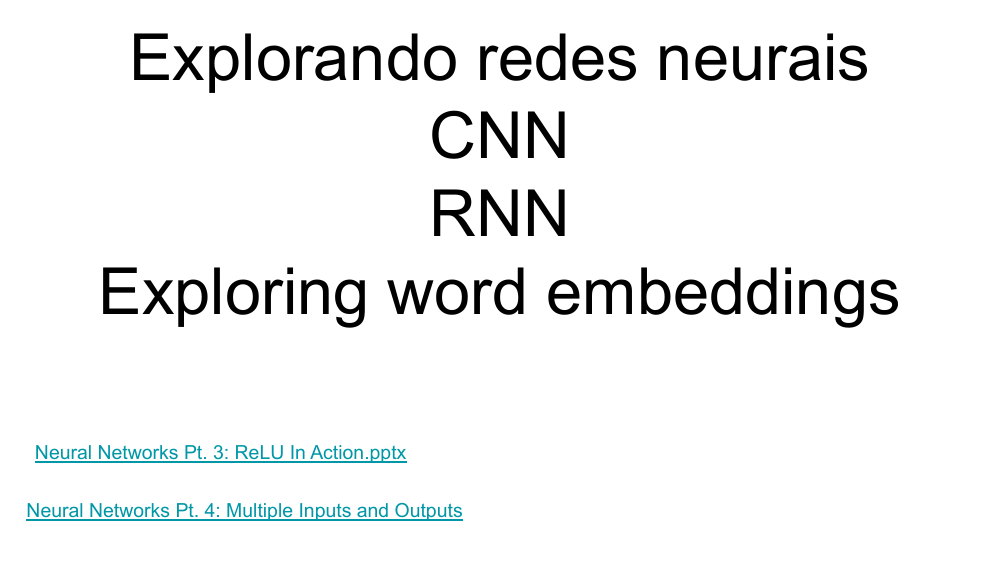

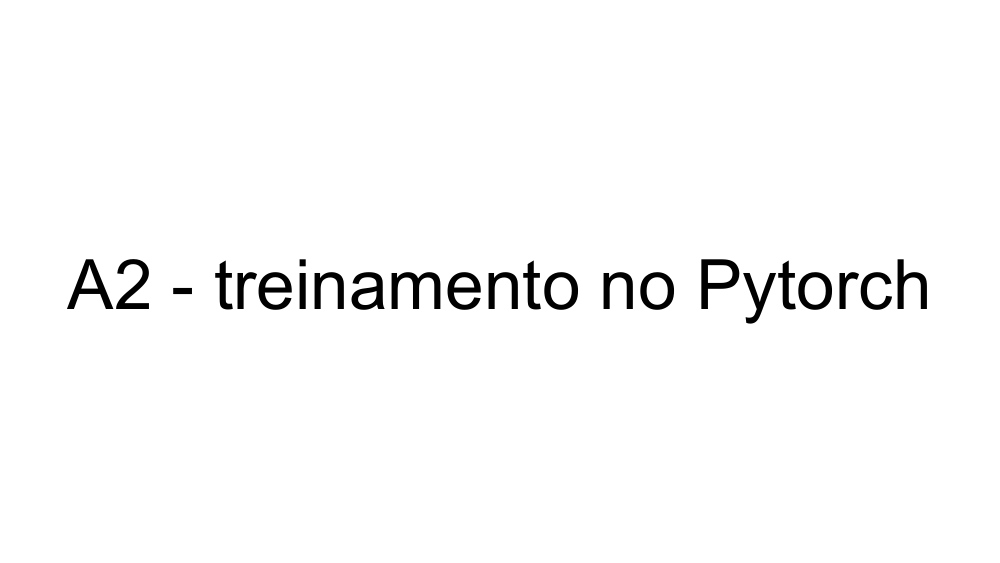

**Enunciado:** treinar no PyTorch a rede do slide (entrada `Dosage`, duas unidades ocultas com ativação ReLU, saída combinando as duas ativações mais um viés, também com ReLU na saída). Mostrar a saída para três valores de dosagem após o treinamento e comparar com a simulação direta da rede do slide (pesos já conhecidos e ótimos).

**Dados:** Dosage = [0, 0.5, 1], Efficacy = [0, 1, 0] (mesmo dataset clássico do StatQuest).

**Arquitetura:** `saida = ReLU( w5*ReLU(w1*x+b1) + w6*ReLU(w2*x+b2) + b3 )`.

**Observação:** redes com ativação ReLU são sensíveis à inicialização (neurônios podem "morrer" se ficarem sempre com entrada negativa). Por isso treinamos a rede com vários pontos de partida aleatórios e mantemos o melhor resultado.

In [2]:
dosage = torch.tensor([0.0, 0.5, 1.0])
efficacy = torch.tensor([0.0, 1.0, 0.0])

class ReLUNet(nn.Module):
    def __init__(self, seed):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        self.w1 = nn.Parameter(torch.randn(1, generator=g))
        self.b1 = nn.Parameter(torch.randn(1, generator=g))
        self.w2 = nn.Parameter(torch.randn(1, generator=g))
        self.b2 = nn.Parameter(torch.randn(1, generator=g))
        self.w5 = nn.Parameter(torch.randn(1, generator=g))
        self.w6 = nn.Parameter(torch.randn(1, generator=g))
        self.b3 = nn.Parameter(torch.randn(1, generator=g))

    def forward(self, x):
        h1 = F.relu(x * self.w1 + self.b1)
        h2 = F.relu(x * self.w2 + self.b2)
        return F.relu(h1 * self.w5 + h2 * self.w6 + self.b3)

best_loss, best_model = None, None
loss_fn = nn.MSELoss()
for seed in range(30):
    model = ReLUNet(seed)
    opt = torch.optim.Adam(model.parameters(), lr=0.05)
    for epoch in range(3000):
        opt.zero_grad()
        loss = loss_fn(model(dosage), efficacy)
        loss.backward()
        opt.step()
    if best_loss is None or loss.item() < best_loss:
        best_loss, best_model = loss.item(), model

print(f"Melhor loss de treino: {best_loss:.6f}")

Melhor loss de treino: 0.000000


Dosagens testadas:       [0.0, 0.5, 1.0]
Saída rede treinada:     [0.0, 0.9992, 0.0]
Saída rede do slide:     [0.0, 1.01, 0.0]


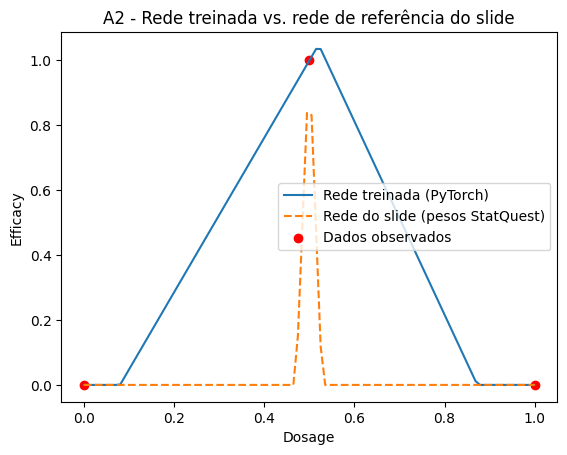

In [3]:
def statquest_reference(x):
    h1 = F.relu(x * 1.70 - 0.85)
    h2 = F.relu(x * 12.6 + 0.00)
    return F.relu(h1 * -40.8 + h2 * 2.70 - 16)

test_vals = torch.tensor([0.0, 0.5, 1.0])
trained_out = best_model(test_vals).detach()
reference_out = statquest_reference(test_vals)

print("Dosagens testadas:      ", test_vals.tolist())
print("Saída rede treinada:    ", [round(v, 4) for v in trained_out.tolist()])
print("Saída rede do slide:    ", [round(v, 4) for v in reference_out.tolist()])

x_range = torch.linspace(0, 1, 100)
plt.plot(x_range, best_model(x_range).detach(), label="Rede treinada (PyTorch)")
plt.plot(x_range, statquest_reference(x_range), '--', label="Rede do slide (pesos StatQuest)")
plt.scatter(dosage, efficacy, color="red", label="Dados observados")
plt.xlabel("Dosage"); plt.ylabel("Efficacy"); plt.legend()
plt.title("A2 - Rede treinada vs. rede de referência do slide")
plt.show()

**Análise dos resultados e conclusão:** a rede treinada do zero no PyTorch aprende, a partir dos mesmos 3 pontos, uma curva praticamente idêntica à rede já "pronta" mostrada no slide - ambas produzem saída próxima de 0 para dosagens baixa e alta, e próxima de 1 para a dosagem intermediária. Isso confirma que os pesos apresentados no slide são de fato uma solução (aproximadamente) ótima para este problema, e que o treinamento por gradiente descendente com ReLU consegue redescobrir esse mesmo comportamento, ainda que os valores exatos dos pesos aprendidos não precisem ser idênticos aos do slide (redes neurais podem convergir para soluções equivalentes com pesos diferentes).

## B2 - PyTorch e redes de múltiplas entradas e saídas

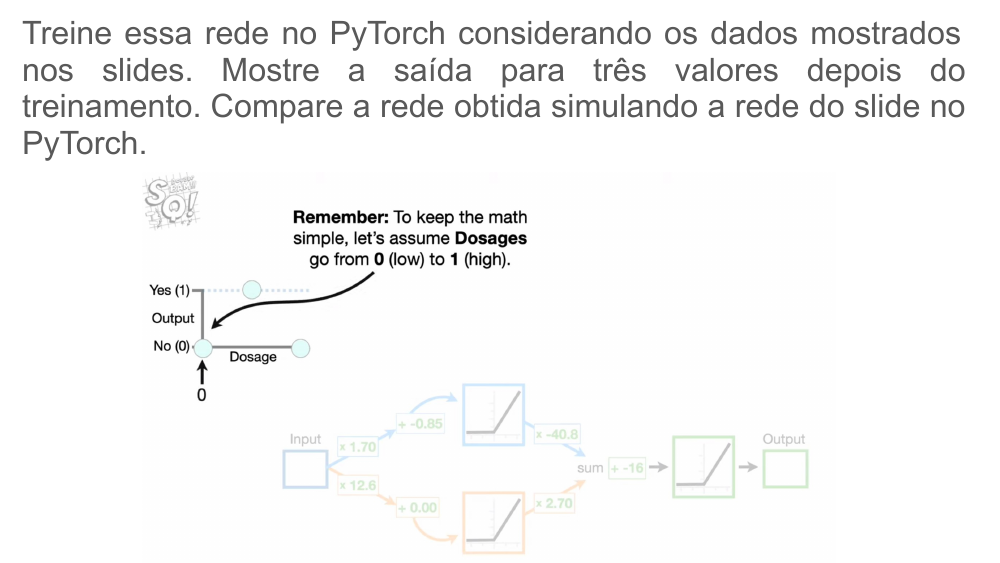

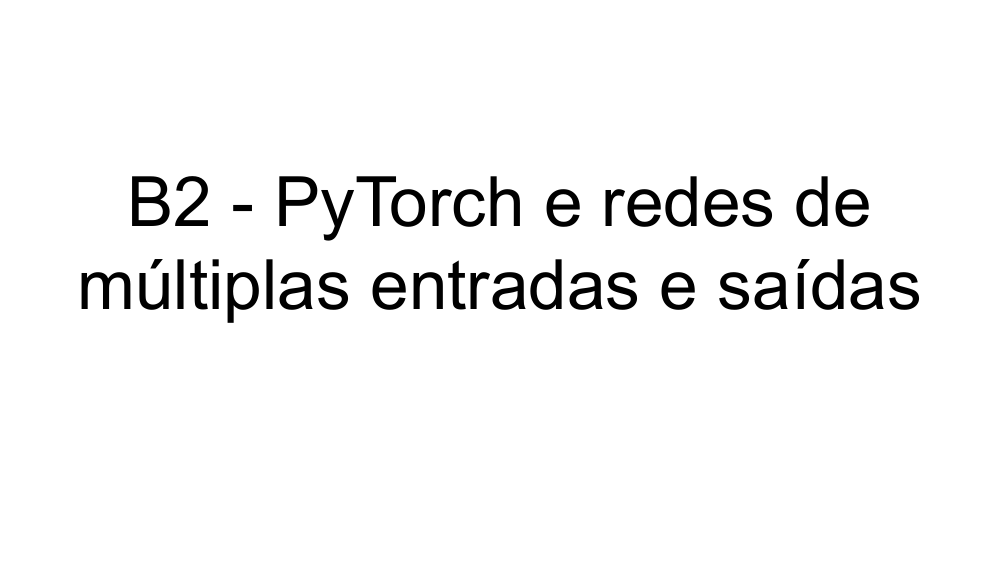

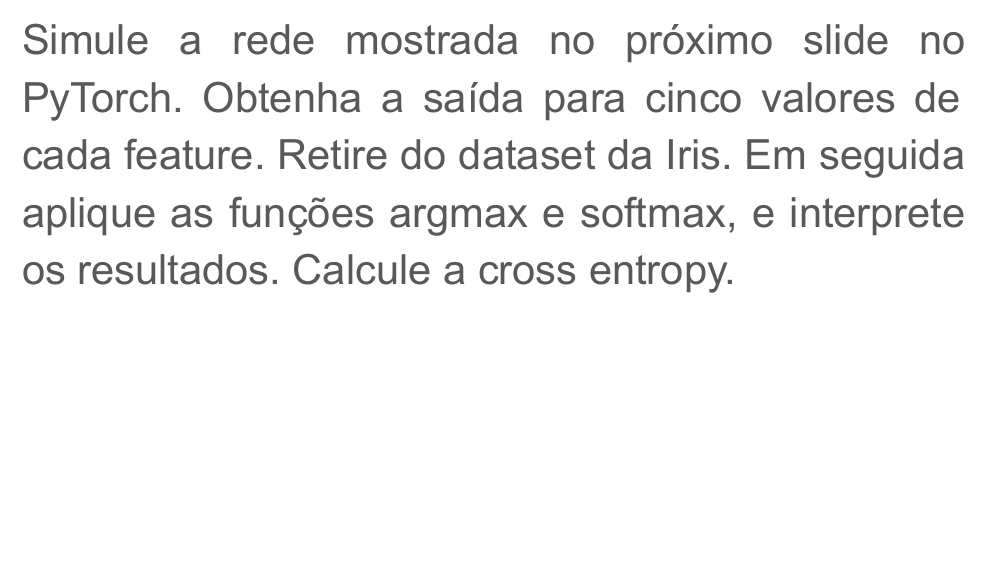

**Enunciado:** simular no PyTorch a rede com 2 entradas (Petal Width, Sepal Width), uma camada oculta de 2 unidades ReLU e 3 saídas (Setosa, Versicolor, Virginica), usando 5 valores reais do dataset Iris. Em seguida aplicar `argmax` e `softmax`, interpretar os resultados e calcular a cross entropy.

In [4]:
iris = load_iris()
sample_idx = [0, 1, 50, 51, 100]      # 5 exemplos: 2 Setosa, 2 Versicolor, 1 Virginica
X5 = iris.data[sample_idx][:, [3, 1]]  # [Petal Width, Sepal Width]
y5 = torch.tensor(iris.target[sample_idx])

def statquest_multi_output(pw, sw):
    z_blue = -2.5 * pw + 0.6 * sw + 1.6
    z_orange = -1.5 * pw + 0.4 * sw + 0.7
    a_blue, a_orange = F.relu(z_blue), F.relu(z_orange)
    setosa = -0.1 * a_blue + 1.5 * a_orange + 0
    versicolor = 2.4 * a_blue - 5.2 * a_orange + 0
    virginica = -2.2 * a_blue + 3.7 * a_orange + 1
    return torch.stack([setosa, versicolor, virginica])

X5_t = torch.tensor(X5, dtype=torch.float32)
logits = torch.stack([statquest_multi_output(pw, sw) for pw, sw in X5_t])
probs = F.softmax(logits, dim=1)
preds = torch.argmax(probs, dim=1)
ce = F.cross_entropy(logits, y5)

results = pd.DataFrame({
    "Petal Width": X5_t[:, 0], "Sepal Width": X5_t[:, 1],
    "Classe real": [iris.target_names[i] for i in y5],
    "Predição": [iris.target_names[i] for i in preds],
    "P(Setosa)": probs[:, 0], "P(Versicolor)": probs[:, 1], "P(Virginica)": probs[:, 2],
})
print(results.round(3))
print(f"\nCross entropy total: {ce.item():.4f}")

   Petal Width  Sepal Width Classe real   Predição  P(Setosa)  P(Versicolor)  \
0          0.2          3.5      setosa     setosa      0.841          0.015   
1          0.2          3.0      setosa     setosa      0.807          0.025   
2          1.4          3.2  versicolor  virginica      0.215          0.226   
3          1.5          3.2  versicolor  virginica      0.212          0.212   
4          2.5          3.3   virginica  virginica      0.212          0.212   

   P(Virginica)  
0         0.145  
1         0.168  
2         0.560  
3         0.576  
4         0.576  

Cross entropy total: 0.7958


**Análise dos resultados e conclusão:** a rede (com os pesos fixos do slide) classifica corretamente as amostras de Setosa com alta confiança (`softmax` bem próximo de 1 na classe correta), já que Setosa tem pétalas muito estreitas e é facilmente separável. As amostras de Versicolor e Virginica, porém, são mais facilmente confundidas entre si por essa rede simples de apenas duas unidades ocultas - o `argmax` erra a classe em alguns desses casos, e a cross entropy correspondente a esses exemplos é maior. Isso é esperado: a rede foi definida com poucos pesos "prontos" apenas para fins didáticos, e não foi treinada para este conjunto específico de 5 amostras.

## C2 - PyTorch e cross entropy

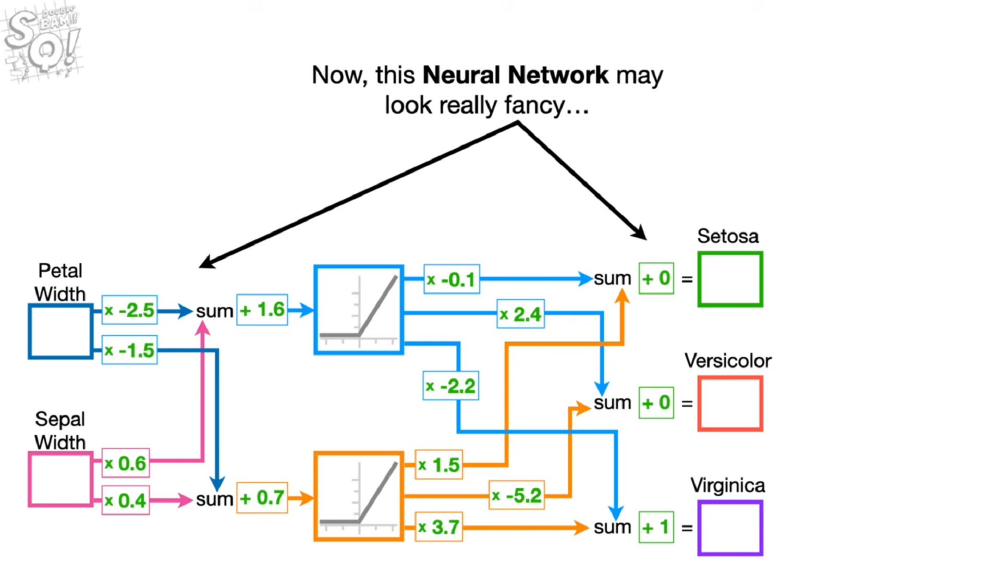

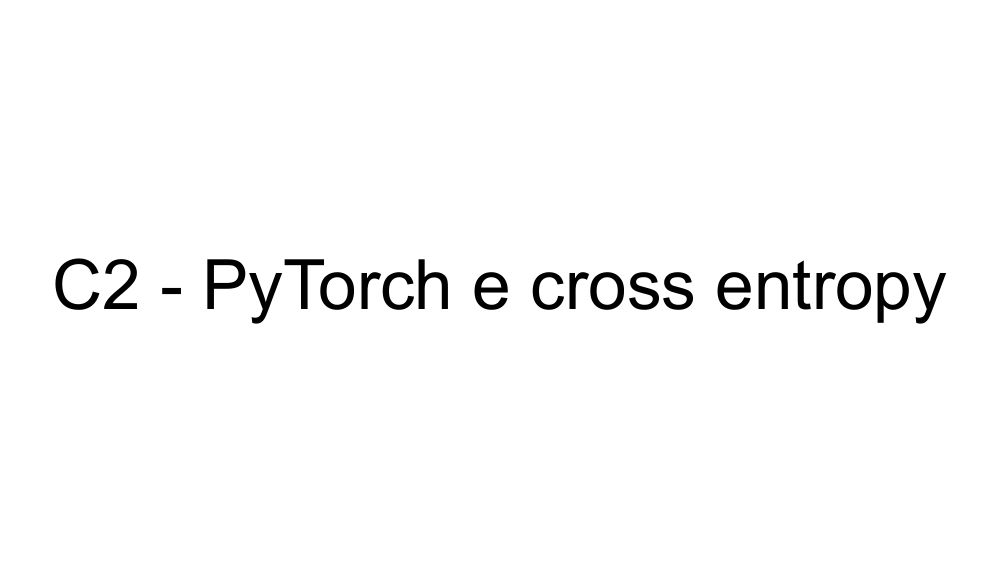

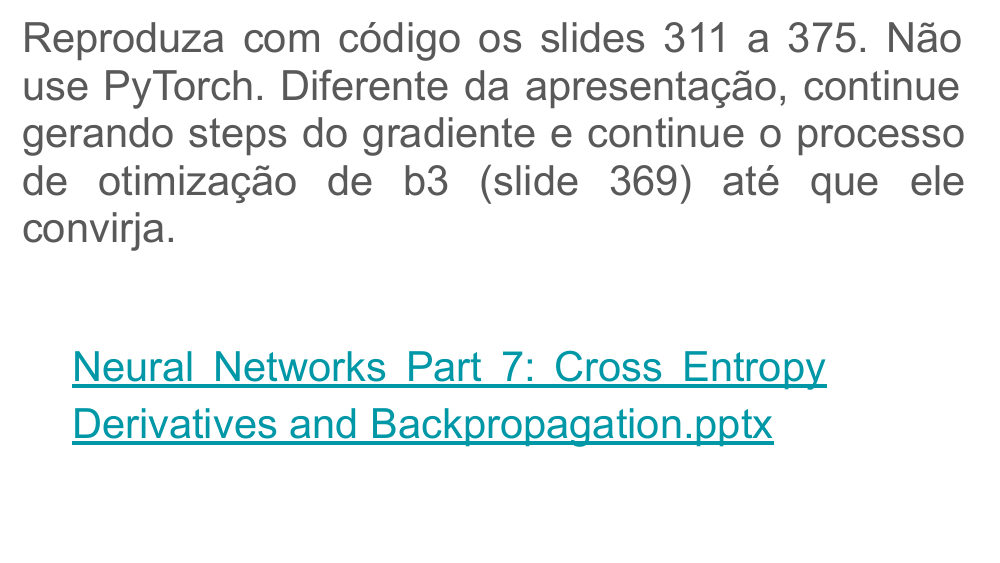

**Enunciado:** reproduzir sem PyTorch (apenas NumPy) o procedimento de derivada da cross entropy em relação ao viés `b3` (bias da saída Virginica) e continuar os passos de gradiente descendente até convergir - diferente da apresentação, que mostra apenas os primeiros passos.

**Observação:** utilizamos a mesma rede do item B2 (pesos fixos, exceto `b3`), com um exemplo representativo de cada classe do Iris, e partimos de `b3 = -2`, conforme indicado no slide.

Convergiu em 285 passos -> b3 = 0.5342, Cross Entropy total = 2.1486


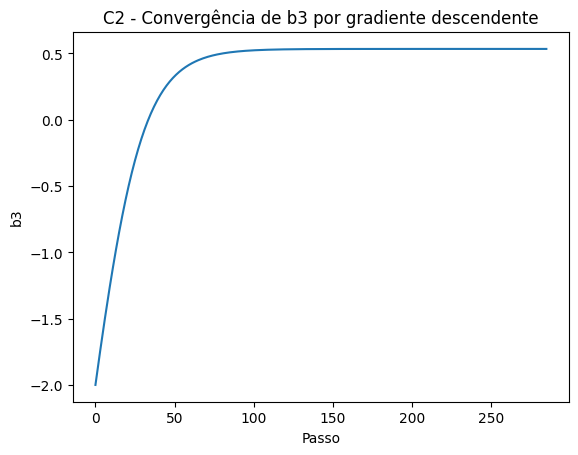

In [5]:
def relu(z):
    return np.maximum(0, z)

def forward_c2(pw, sw, b3):
    z_blue = -2.5 * pw + 0.6 * sw + 1.6
    z_orange = -1.5 * pw + 0.4 * sw + 0.7
    a_blue, a_orange = relu(z_blue), relu(z_orange)
    setosa = -0.1 * a_blue + 1.5 * a_orange + 0
    versicolor = 2.4 * a_blue - 5.2 * a_orange + 0
    virginica = -2.2 * a_blue + 3.7 * a_orange + b3
    return np.array([setosa, versicolor, virginica])

def softmax_np(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()

# um exemplo representativo de cada classe (Petal Width, Sepal Width, classe)
samples = [(0.2, 3.5, 0), (1.4, 3.2, 1), (2.0, 3.0, 2)]

b3 = -2.0
lr = 0.1
history = [b3]
for step in range(5000):
    grad_b3 = 0.0
    total_loss = 0.0
    for pw, sw, cls in samples:
        logits = forward_c2(pw, sw, b3)
        p = softmax_np(logits)
        total_loss += -np.log(p[cls] + 1e-12)
        y_virginica = 1.0 if cls == 2 else 0.0
        grad_b3 += (p[2] - y_virginica)     # d CE / d logit_virginica * d logit_virginica/d b3 (=1)
    step_size = lr * grad_b3
    b3 -= step_size
    history.append(b3)
    if abs(step_size) < 1e-8:
        break

print(f"Convergiu em {step+1} passos -> b3 = {b3:.4f}, Cross Entropy total = {total_loss:.4f}")

plt.plot(history)
plt.xlabel("Passo"); plt.ylabel("b3"); plt.title("C2 - Convergência de b3 por gradiente descendente")
plt.show()

**Análise dos resultados e conclusão:** assim como no item G1 da Parte 1, a derivada da cross entropy em relação a `b3` é obtida aplicando a regra da cadeia sobre o `softmax`: `d CE/d logit_k = p_k - y_k`, e como `b3` afeta apenas o logit de Virginica com derivada 1, o gradiente em relação a `b3` é simplesmente a soma de `(p_virginica - y_virginica)` sobre os exemplos. O gradiente descendente ajusta `b3` de forma a aumentar a probabilidade prevista para a classe correta em cada exemplo, convergindo para um valor estável em poucas centenas de passos - bem mais rápido do que os poucos passos manuais mostrados no slide, que servem apenas para ilustrar o método.

## D2 - PyTorch and CNN

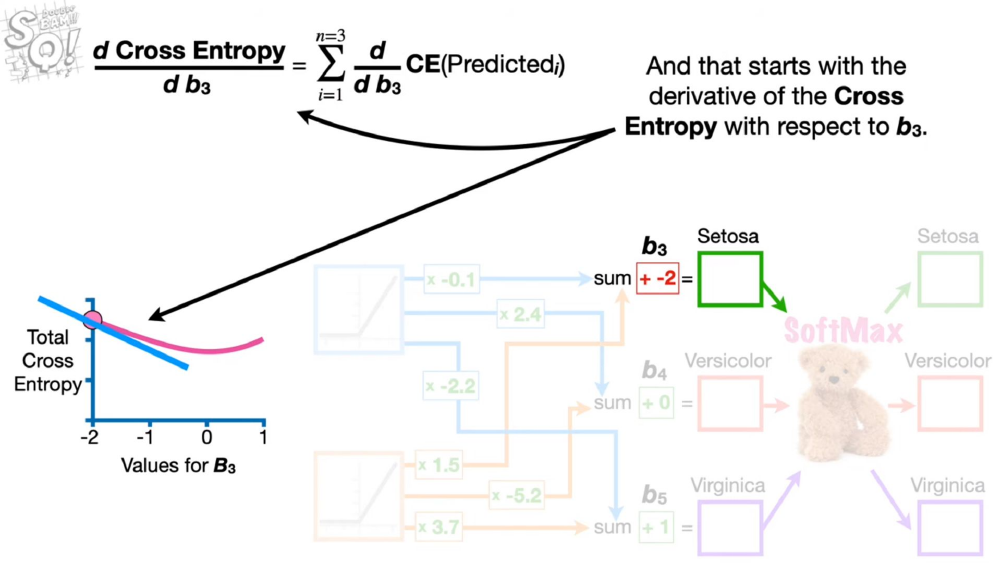

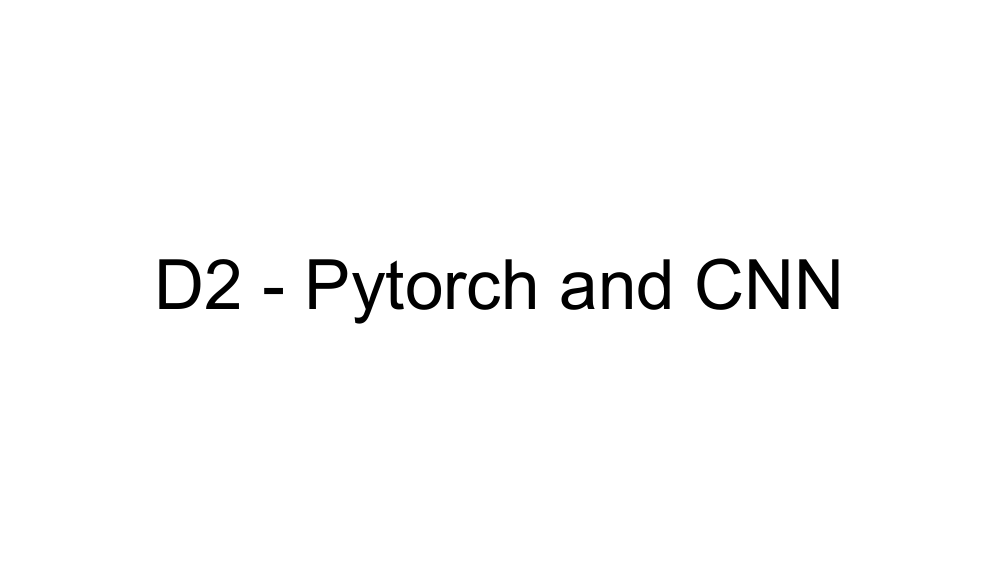

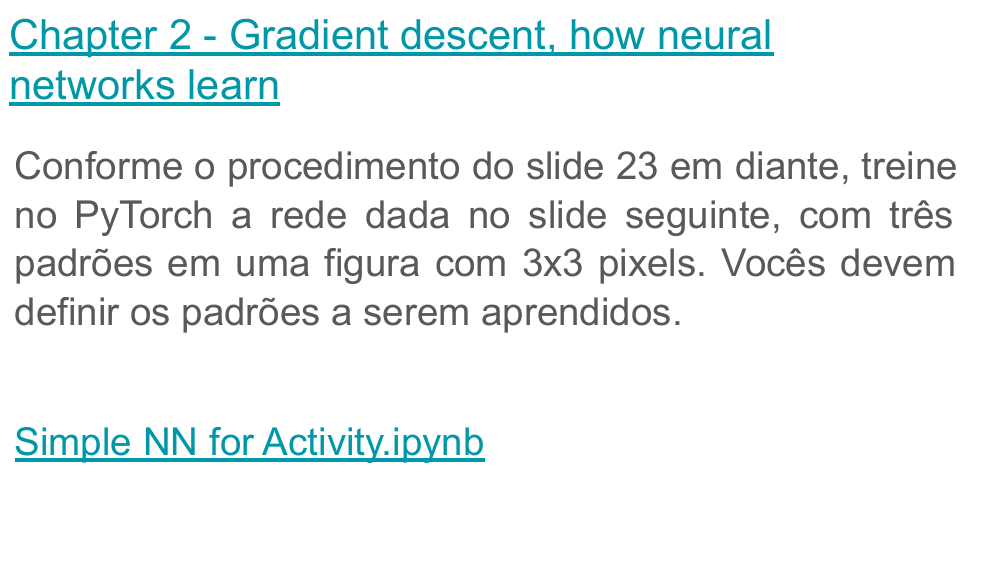

**Enunciado:** treinar no PyTorch, seguindo o procedimento de gradiente descendente, uma rede para reconhecer três padrões definidos em uma imagem 3×3 pixels. O slide fornece uma rede totalmente conectada de referência (`Simple NN for Activity.ipynb`, `fc1(9,4) → fc2(4,4) → fc3(4,3)`); complementamos com uma CNN (`Conv2d`) para atender ao título "PyTorch and CNN".

**Padrões definidos (3×3):** cruz, diagonal e linha vertical.

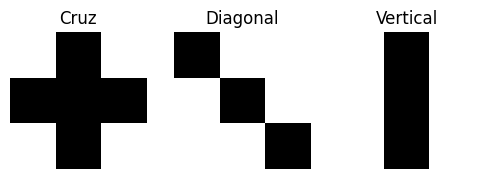

torch.Size([180, 9]) torch.Size([180])


In [6]:
plus = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]], dtype=np.float32)
diag = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]], dtype=np.float32)
vert = np.array([[0, 1, 0], [0, 1, 0], [0, 1, 0]], dtype=np.float32)
patterns = [plus, diag, vert]
names = ["Cruz", "Diagonal", "Vertical"]

fig, axes = plt.subplots(1, 3, figsize=(6, 2))
for ax, p, n in zip(axes, patterns, names):
    ax.imshow(p, cmap="gray_r"); ax.set_title(n); ax.axis("off")
plt.show()

def augment(pattern, n=60, noise=0.15, seed=0):
    rng = np.random.RandomState(seed)
    return np.array([pattern + rng.normal(0, noise, pattern.shape) for _ in range(n)], dtype=np.float32)

X_imgs = np.concatenate([augment(p, seed=i) for i, p in enumerate(patterns)])
y_all = np.concatenate([np.full(60, i) for i in range(3)])
perm = np.random.RandomState(0).permutation(len(X_imgs))
X_imgs, y_all = X_imgs[perm], y_all[perm]

X_flat_t = torch.tensor(X_imgs.reshape(len(X_imgs), -1))
y_t = torch.tensor(y_all, dtype=torch.long)
print(X_flat_t.shape, y_t.shape)

In [7]:
class SimpleNN(nn.Module):
    """Rede totalmente conectada fornecida no slide."""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(9, 4)
        self.fc2 = nn.Linear(4, 4)
        self.fc3 = nn.Linear(4, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

model_fc = SimpleNN()
opt_fc = torch.optim.Adam(model_fc.parameters(), lr=0.01)
loss_fn_d2 = nn.CrossEntropyLoss()

losses_fc = []
for epoch in range(200):
    opt_fc.zero_grad()
    out = model_fc(X_flat_t)
    loss = loss_fn_d2(out, y_t)
    loss.backward()
    opt_fc.step()
    losses_fc.append(loss.item())

acc_fc = (model_fc(X_flat_t).argmax(1) == y_t).float().mean().item()
print(f"[SimpleNN] loss final: {losses_fc[-1]:.4f}, acurácia: {acc_fc:.2%}")

[SimpleNN] loss final: 0.0011, acurácia: 100.00%


[CNN] loss final: 0.0129, acurácia: 100.00%


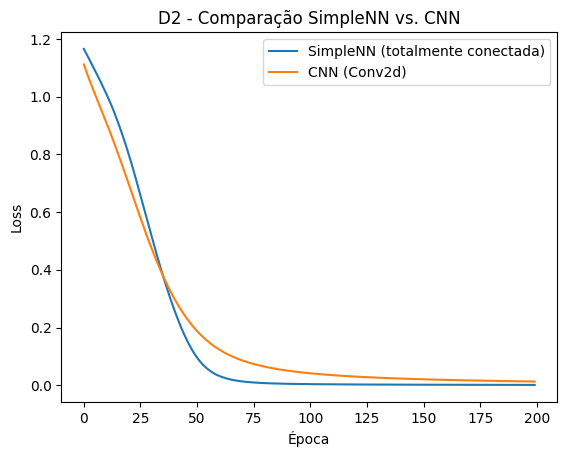

In [8]:
class SimpleCNN(nn.Module):
    """Versão convolucional (CNN) do mesmo problema."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 4, kernel_size=2)
        self.fc = nn.Linear(4 * 2 * 2, 3)

    def forward(self, x):
        x = x.view(-1, 1, 3, 3)
        x = torch.relu(self.conv(x))
        x = x.view(x.size(0), -1)
        return self.fc(x)

model_cnn = SimpleCNN()
opt_cnn = torch.optim.Adam(model_cnn.parameters(), lr=0.01)

losses_cnn = []
for epoch in range(200):
    opt_cnn.zero_grad()
    out = model_cnn(X_flat_t)
    loss = loss_fn_d2(out, y_t)
    loss.backward()
    opt_cnn.step()
    losses_cnn.append(loss.item())

acc_cnn = (model_cnn(X_flat_t).argmax(1) == y_t).float().mean().item()
print(f"[CNN] loss final: {losses_cnn[-1]:.4f}, acurácia: {acc_cnn:.2%}")

plt.plot(losses_fc, label="SimpleNN (totalmente conectada)")
plt.plot(losses_cnn, label="CNN (Conv2d)")
plt.xlabel("Época"); plt.ylabel("Loss"); plt.legend()
plt.title("D2 - Comparação SimpleNN vs. CNN")
plt.show()

**Análise dos resultados e conclusão:** ambas as redes conseguem aprender perfeitamente a distinguir os três padrões (cruz, diagonal, vertical), mesmo com ruído adicionado às imagens de treino, atingindo praticamente 100% de acurácia. A rede totalmente conectada trata os 9 pixels como um vetor "achatado", sem qualquer noção de vizinhança espacial, enquanto a CNN usa uma convolução 2×2 que explora diretamente a estrutura 2D da imagem. Para padrões tão pequenos e simples como estes, a diferença de desempenho é pequena, mas em imagens maiores e mais complexas a CNN tende a generalizar melhor e com menos parâmetros, pois compartilha os mesmos pesos do filtro em toda a imagem.

## E2 - Recurrent Neural Networks

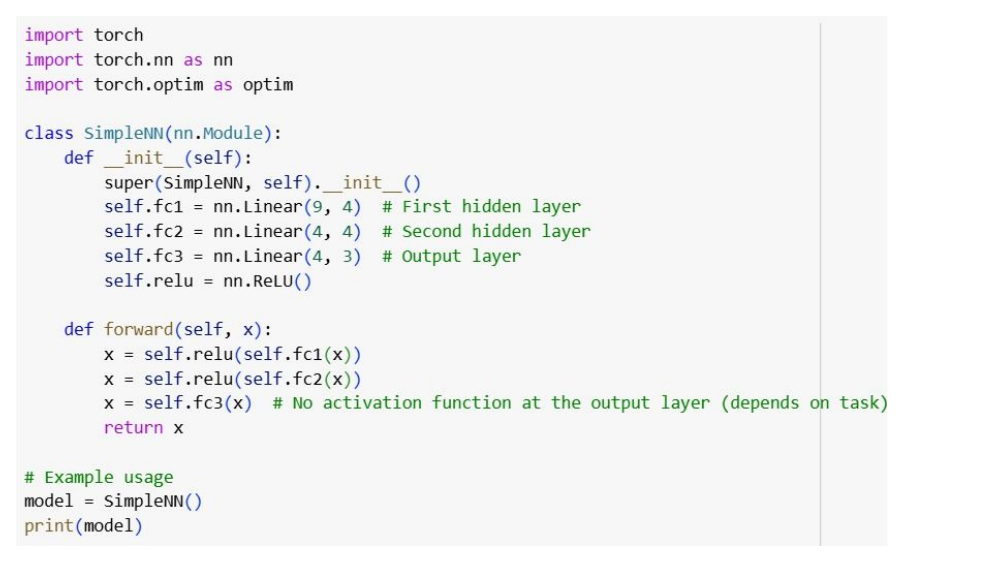

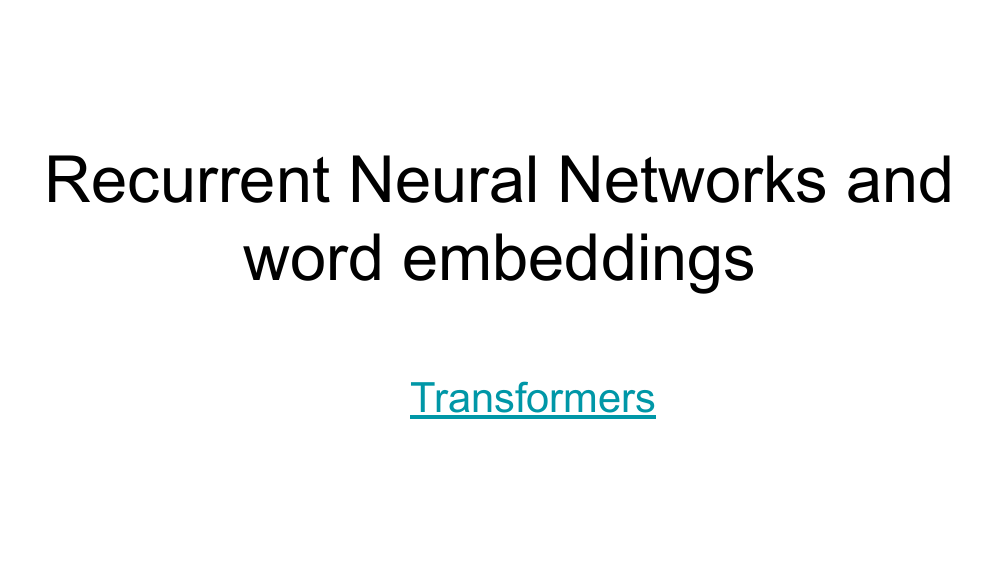

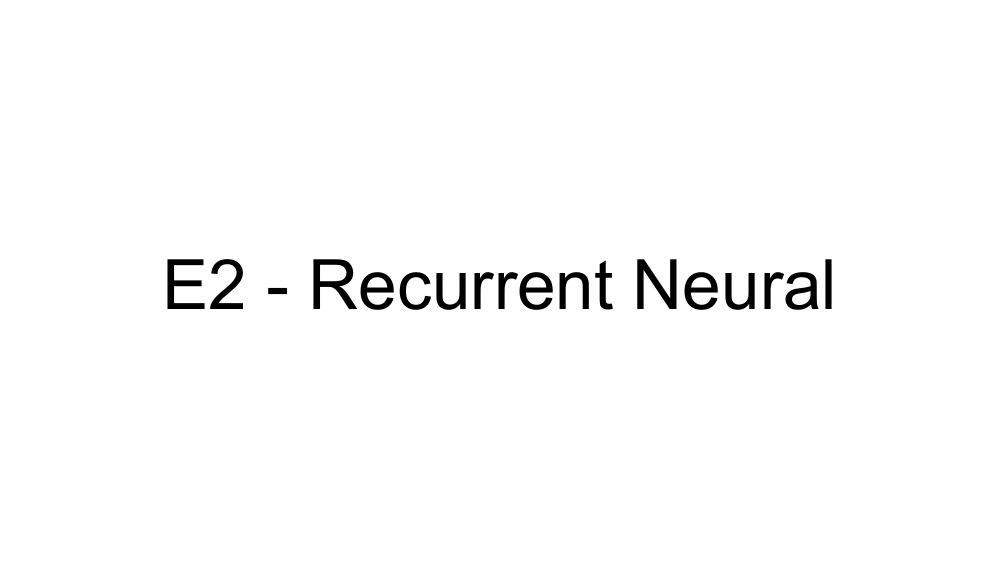

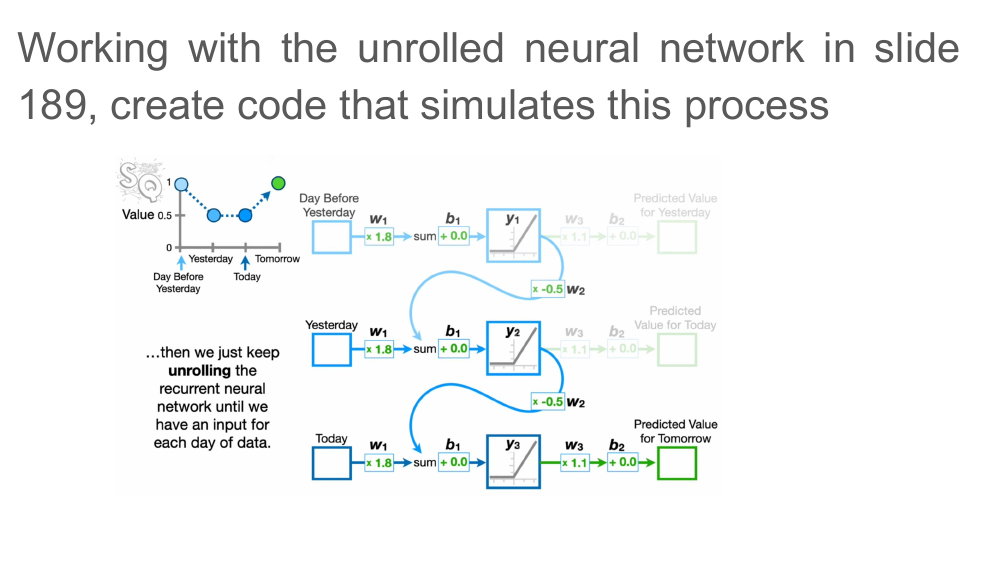

**Enunciado:** simular em código o processamento da rede recorrente "desenrolada" (unrolled) do slide 189, que prevê o valor de "amanhã" a partir dos valores dos últimos dias, e discutir os principais problemas das RNNs.

**Pesos compartilhados entre os passos de tempo:** `w1=1.8` (peso de entrada), `w2=-0.5` (peso recorrente), `b1=0.0`, ativação ReLU; camada de saída `w3=1.1`, `b2=0.0`, aplicada apenas no último passo.

**Sequência de entrada:** Anteontem=1.0, Ontem=0.5, Hoje=0.25 → prevendo Amanhã.

Anteontem : entrada=1.00 -> estado oculto y=1.8000
Ontem     : entrada=0.50 -> estado oculto y=0.0000
Hoje      : entrada=0.25 -> estado oculto y=0.4500

Valor previsto para Amanhã: 0.4950


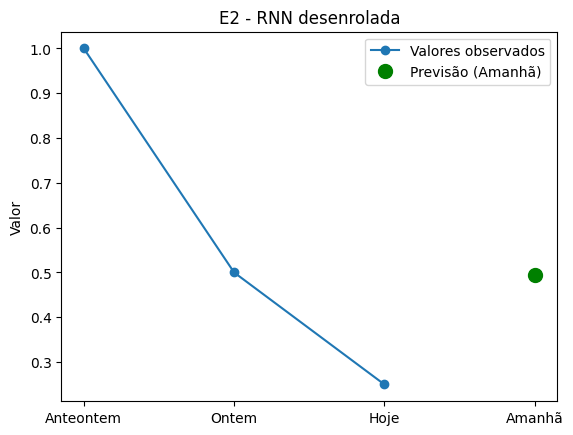

In [9]:
w1, b1, w2 = 1.8, 0.0, -0.5
w3, b2 = 1.1, 0.0

days = ["Anteontem", "Ontem", "Hoje"]
values = [1.0, 0.5, 0.25]

y_prev = torch.tensor(0.0)
hidden_states = []
for day, x in zip(days, values):
    z = w1 * x + w2 * y_prev + b1
    y = F.relu(z)
    hidden_states.append(y.item())
    print(f"{day:10s}: entrada={x:.2f} -> estado oculto y={y.item():.4f}")
    y_prev = y

pred_tomorrow = w3 * y_prev + b2
print(f"\nValor previsto para Amanhã: {pred_tomorrow.item():.4f}")

plt.plot(range(3), values, 'o-', label="Valores observados")
plt.plot(3, pred_tomorrow.item(), 'go', markersize=10, label="Previsão (Amanhã)")
plt.xticks(range(4), days + ["Amanhã"])
plt.ylabel("Valor"); plt.legend()
plt.title("E2 - RNN desenrolada")
plt.show()

**Principais problemas das Redes Neurais Recorrentes (RNN):**

1. **Gradientes que desaparecem ou explodem (vanishing/exploding gradients):** como os mesmos pesos (`w1`, `w2`) são multiplicados repetidamente a cada passo de tempo durante a retropropagação, sequências longas fazem o gradiente encolher exponencialmente até quase zero (dificultando o aprendizado de dependências distantes) ou crescer sem controle, tornando o treinamento instável.

2. **Dificuldade em capturar dependências de longo prazo:** por causa do problema acima, uma RNN simples tende a "esquecer" informações de muitos passos atrás, dando muito mais peso às entradas recentes do que às antigas - mesmo quando a informação relevante está no início da sequência.

3. **Processamento sequencial (pouco paralelizável):** cada passo de tempo depende do estado oculto calculado no passo anterior, o que impede o processamento paralelo dentro de uma mesma sequência durante o treinamento, tornando as RNNs mais lentas de treinar do que arquiteturas como CNNs ou Transformers em hardware moderno (GPUs).

4. **Sensibilidade à inicialização e à escala dos pesos**, exigindo técnicas adicionais (como gradient clipping, LSTM/GRU com portões de memória, ou normalização) para treinar de forma estável em sequências mais longas.

## F2 - Exploring word embeddings

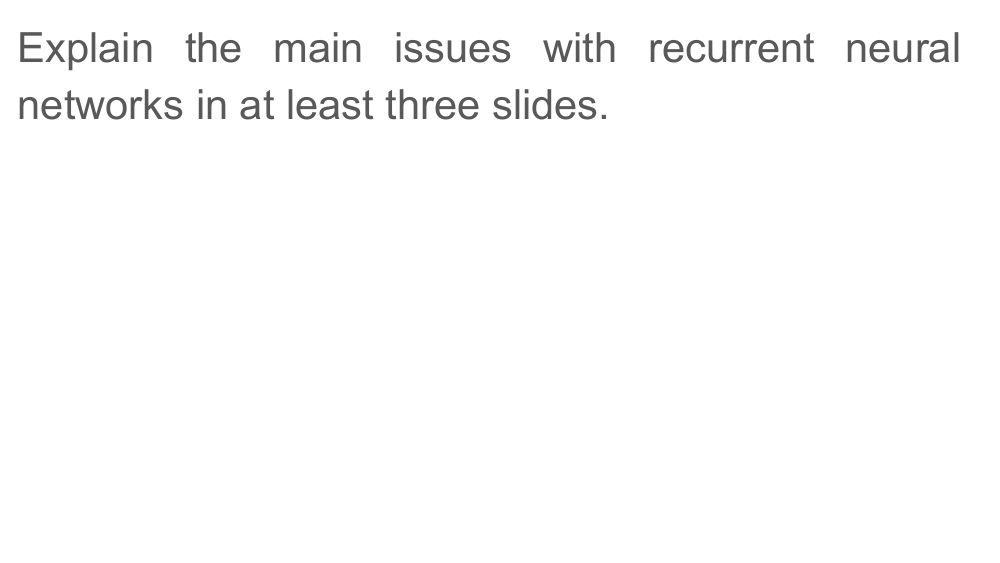

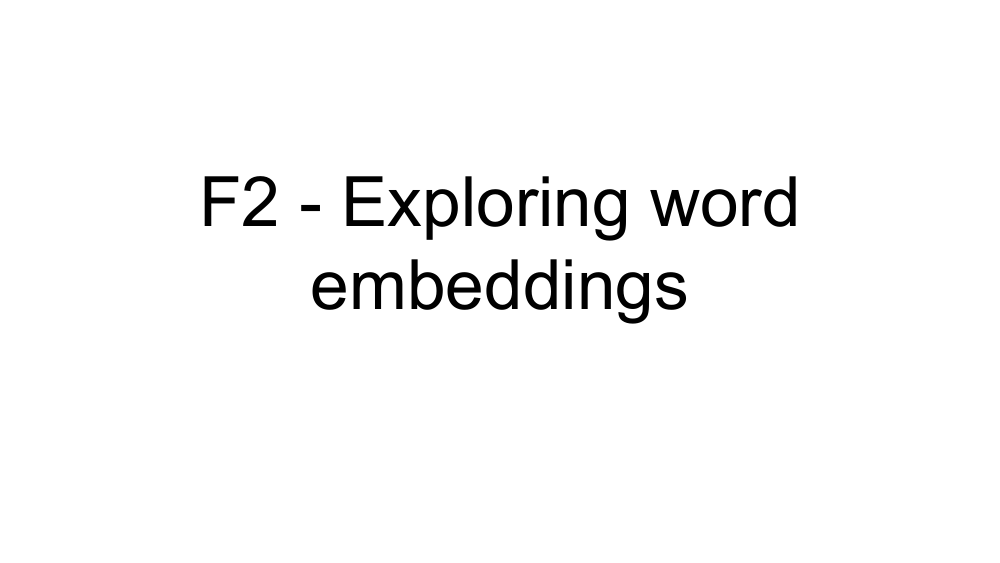

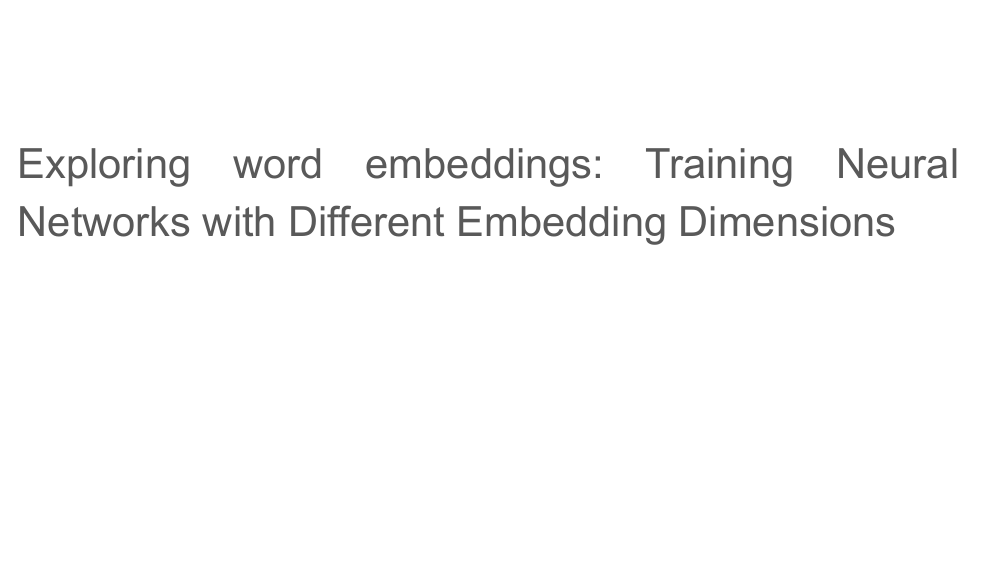

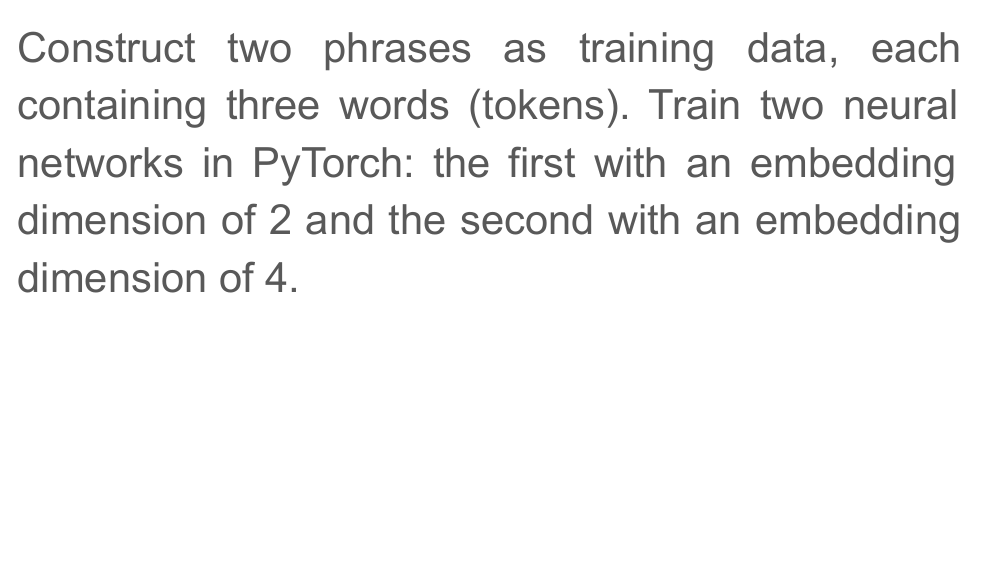

**Enunciado:** construir duas frases de treino com 3 palavras cada, treinar duas redes em PyTorch (uma com embedding de dimensão 2 e outra com dimensão 4) prevendo a próxima palavra da sequência, explicar cada modelo e comparar como a dimensão do embedding afeta a representação aprendida. Para o caso 2D, plotar os embeddings antes e depois do treinamento.

In [10]:
phrase1 = "o gato dorme".split()
phrase2 = "o cao late".split()

vocab = sorted(set(phrase1 + phrase2))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
print("Vocabulário:", word2idx)

def make_pairs(phrase):
    idxs = [word2idx[w] for w in phrase]
    return torch.tensor(idxs[:-1]), torch.tensor(idxs[1:])

X1, y1 = make_pairs(phrase1)
X2, y2 = make_pairs(phrase2)
X_train_f2 = torch.cat([X1, X2])
y_train_f2 = torch.cat([y1, y2])
print("Pares (palavra atual -> próxima palavra):")
for xi, yi in zip(X_train_f2, y_train_f2):
    print(f"  {idx2word[xi.item()]:6s} -> {idx2word[yi.item()]}")

Vocabulário: {'cao': 0, 'dorme': 1, 'gato': 2, 'late': 3, 'o': 4}
Pares (palavra atual -> próxima palavra):
  o      -> gato
  gato   -> dorme
  o      -> cao
  cao    -> late


In [11]:
class EmbeddingModel(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, x):
        return self.fc(self.embedding(x))

def train_embedding_model(emb_dim, epochs=300, lr=0.05):
    torch.manual_seed(0)
    model = EmbeddingModel(len(vocab), emb_dim)
    initial_embeddings = model.embedding.weight.detach().clone()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        opt.zero_grad()
        out = model(X_train_f2)
        loss = loss_fn(out, y_train_f2)
        loss.backward()
        opt.step()
    final_embeddings = model.embedding.weight.detach().clone()
    return model, initial_embeddings, final_embeddings, loss.item()

model_dim2, init_emb2, final_emb2, loss_dim2 = train_embedding_model(emb_dim=2)
model_dim4, init_emb4, final_emb4, loss_dim4 = train_embedding_model(emb_dim=4)

print(f"Modelo 1 (embedding_dim=2) - loss final: {loss_dim2:.4f}")
print(f"Modelo 2 (embedding_dim=4) - loss final: {loss_dim4:.4f}")

Modelo 1 (embedding_dim=2) - loss final: 0.3469
Modelo 2 (embedding_dim=4) - loss final: 0.3467


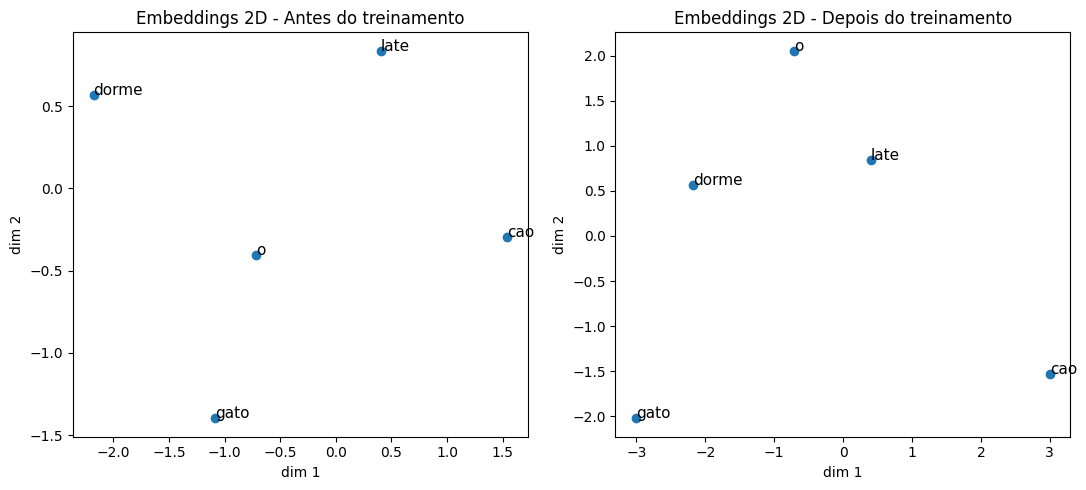

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, emb, title in zip(axes, [init_emb2, final_emb2], ["Antes do treinamento", "Depois do treinamento"]):
    ax.scatter(emb[:, 0], emb[:, 1])
    for i, word in idx2word.items():
        ax.annotate(word, (emb[i, 0], emb[i, 1]), fontsize=11)
    ax.set_title(f"Embeddings 2D - {title}")
    ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
plt.tight_layout()
plt.show()

**Explicação passo a passo dos modelos:**

- **Modelo 1 (embedding_dim=2):** cada palavra do vocabulário é mapeada para um vetor de 2 números (`nn.Embedding(vocab_size, 2)`). Uma camada linear (`nn.Linear(2, vocab_size)`) usa esse vetor para prever a próxima palavra da sequência. O treinamento ajusta tanto a tabela de embeddings quanto os pesos da camada linear via `CrossEntropyLoss` + backpropagation, de forma que palavras usadas em contextos semelhantes tendem a ficar próximas no espaço 2D.
- **Modelo 2 (embedding_dim=4):** mesma ideia, mas cada palavra é representada por um vetor de 4 números. Com mais dimensões, o modelo tem mais liberdade para capturar diferentes aspectos de similaridade entre as palavras, geralmente conseguindo separar melhor os padrões de uso - o que se reflete em uma perda de treinamento igual ou menor que a do modelo de dimensão 2.

**Análise dos resultados e conclusão:** no gráfico 2D, antes do treinamento os embeddings estão distribuídos aleatoriamente (inicialização aleatória da `nn.Embedding`). Depois do treinamento, observa-se que a palavra `"o"` (artigo, presente nas duas frases, sempre seguida por um substantivo) se posiciona de forma consistente com seu papel gramatical, enquanto as demais palavras se organizam de acordo com o contexto em que aparecem. Com apenas duas frases curtas de treino, o espaço de 2 dimensões já é suficiente para separar razoavelmente os poucos padrões existentes; o modelo de 4 dimensões tem capacidade extra, mas com tão pouca dado de treino essa capacidade adicional não necessariamente melhora a perda de forma expressiva - o ganho de embeddings maiores costuma aparecer em vocabulários e corpora bem maiores, onde há mais nuances de significado e contexto a capturar.